In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
def DFT(x):
    n = len(x)

    j = np.arange(n).reshape((n, 1))
    k = np.arange(n).reshape((1, n))

    m = j * k

    ksi = np.exp(-2j * np.pi / n)

    F = ksi ** m

    return F, F @ x


In [55]:
def IDFT(F, y):
    n = len(y)

    y_dashed = np.conjugate(y)

    return np.conjugate(F @ y_dashed) / n

In [56]:
def build_P(n):
    P = np.zeros((n, n))
    half = n // 2
    
    for i in range(half):
        P[i, 2 * i] = 1
    for i in range(half):
        P[half + i, 2 * i + 1] = 1
        
    return P

def build_G(m, n):
    diagonal_elements = np.exp(-2j * np.pi * np.arange(m) / n)
    return np.diag(diagonal_elements)

def FFT(n):
    if n <= 1:
        return np.array([[1.0 + 0j]])

    half = n//2

    F = FFT(half)
    G = build_G(half, n)

    P = build_P(n)

    return np.block([
        [F, G @ F],
        [F, -G @ F]
    ]) @ P    

In [57]:
x = [0.1, 2, 4, 5]

F, out = DFT([0.1, 2, 4, 5])
print(IDFT(F, out))

m = FFT(4)
print(out)
print(m @ x)
print(np.fft.fft(x))

[0.1-7.19634740e-16j 2. -4.79375178e-16j 4. -9.79717439e-17j
 5. +2.31229456e-16j]
[11.1+0.00000000e+00j -3.9+3.00000000e+00j -2.9-1.10218212e-15j
 -3.9-3.00000000e+00j]
[11.1+0.j -3.9+3.j -2.9+0.j -3.9-3.j]
[11.1+0.j -3.9+3.j -2.9+0.j -3.9-3.j]


Second part

In [58]:
def generate_signal(A, f, n):
    t = np.arange(n).reshape((n, 1))

    signal = A * np.sin(1 * np.pi * f * t)

    return signal

In [59]:
f = [10, 50, 100, 150, 200]
signals = []

for hz in f:
    signals.append(generate_signal(100, hz, 128))

signal = np.sum(signals, axis=0)


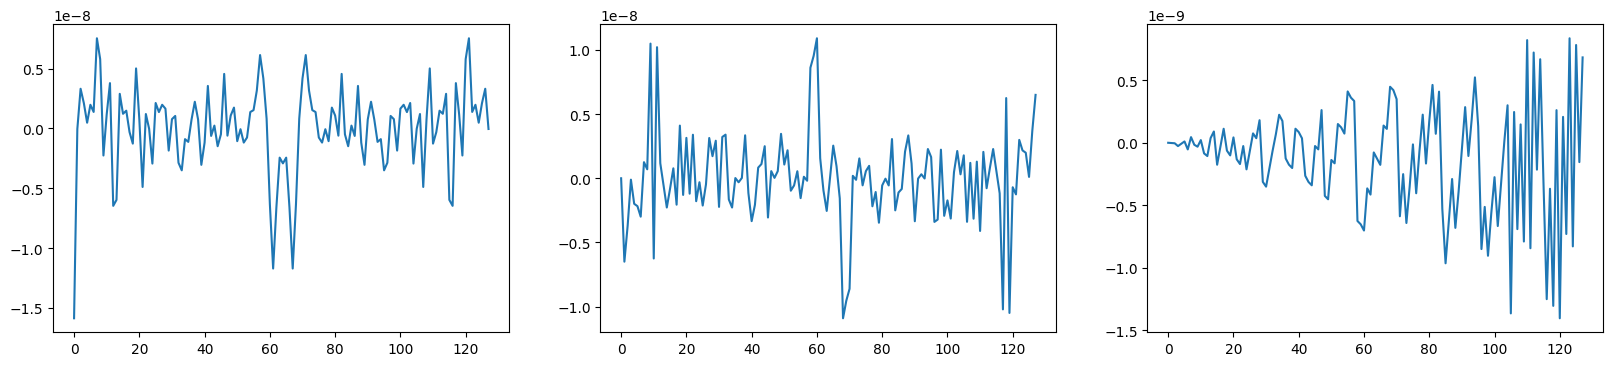

In [60]:
m = FFT(128)

decomp = m @ signal

t = np.arange(128)

real_part = np.real(decomp)
imaginary_part = np.imag(decomp)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))

ax[0].plot(t, real_part)
ax[1].plot(t, imaginary_part)
ax[2].plot(t, signal)
plt.show()


Other signal

In [61]:
f = [10, 50, 100, 150, 200]
signals = []

for hz in f:
    signals.append(generate_signal(10, hz, 32))

signal = np.zeros(32).reshape((32, 1))

signal[0:4] = signals[0][0:4]
signal[4:8] = signals[1][4:8]
signal[8:12] = signals[2][8:12]
signal[12:18] = signals[3][12:18]
signal[18:32] = signals[4][18:32]

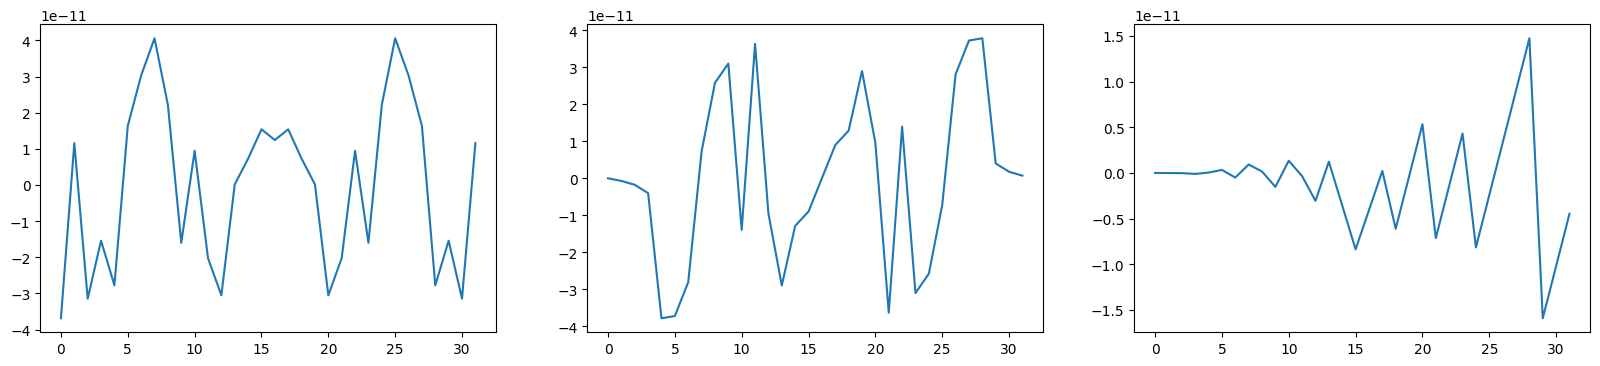

In [62]:
m = FFT(32)

decomp = m @ signal

t = np.arange(32)

real_part = np.real(decomp)
imaginary_part = np.imag(decomp)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))

ax[0].plot(t, real_part)
ax[1].plot(t, imaginary_part)
ax[2].plot(t, signal)
plt.show()
